# Exploratory Data Analysis — Crowdsourcing Platform

**Thesis:** Quality Evaluation and Worker Segmentation in Crowdsourcing Systems  
**Program:** HSE FCS — Master of Data Science (MNAD), 2024-26

---

Each row in the dataset represents **one worker's answer to one task**. Tasks are grouped into pages, pages into pools, and pools into projects. This notebook explores a 100 000-row sample; the full dataset contains **4.12 million rows**.

**Domain glossary**

| Term | Meaning |
|------|---------|
| `pool_type = 0` | **Regular (paid) pool** — production work, workers earn money |
| `pool_type = 1` | **Rehabilitation pool** — control-only, triggered when a worker makes ≥ 2 errors in the last 10 gold tasks |
| `pool_type = 3` | **Training pool** — onboarding exercises before a worker can enter a project |
| `task_type = 0` | **Regular task** — the actual labelling work |
| `task_type = 1` | **Gold (control) task** — task with a known answer, used to monitor quality in real time |
| `task_type = 2` | **Training task** — used only inside training pools |
| `page` | A screen shown to a worker; may contain 1–3 tasks. **Timing is per-page, not per-task.** |
| `overlap` | How many different workers label the same task |

## 0 · Setup

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ── palette ───────────────────────────────────────────────────────────
C = dict(
    blue="#4A90D9", teal="#2BA89E", amber="#E5A832", coral="#E06350",
    purple="#7C6BC4", green="#5AAE61", pink="#D96BA0", gray="#8C8C8C",
    red="#D94F4F", slate="#5C6B7A", light="#F5F5F5",
)
PROJECT_C = {575:"#7C6BC4", 576:"#4A90D9", 577:"#2BA89E", 578:"#E5A832", 581:"#E06350"}
POOL_C    = {0:C["blue"], 1:C["coral"], 3:C["teal"]}

# ── matplotlib style ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.edgecolor":   "#CCCCCC",
    "axes.linewidth":   0.5,
    "axes.grid":        True,
    "grid.color":       "#EEEEEE",
    "grid.linewidth":   0.4,
    "font.family":      "sans-serif",
    "font.size":        10.5,
    "axes.titlesize":   12,
    "axes.titleweight":  600,
    "axes.titlepad":    10,
    "axes.labelsize":   10,
    "axes.labelcolor":  "#444444",
    "xtick.color":      "#666666",
    "ytick.color":      "#666666",
    "figure.dpi":       130,
    "legend.framealpha": 0.85,
    "legend.fontsize":  9,
    "legend.edgecolor": "#DDDDDD",
})

# ── helpers ───────────────────────────────────────────────────────────
def bar_labels(ax, bars, fmt="{:,.0f}", fs=8.5, pad=3, horizontal=False):
    for b in bars:
        v = b.get_width() if horizontal else b.get_height()
        if horizontal:
            ax.text(v + pad, b.get_y() + b.get_height()/2,
                    fmt.format(v), va="center", fontsize=fs, color="#555")
        else:
            ax.text(b.get_x() + b.get_width()/2, v + pad,
                    fmt.format(v), ha="center", fontsize=fs, color="#555")

def despine(ax, left=False):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if left: ax.spines["left"].set_visible(False)

print("Setup complete ✓")

Setup complete ✓


## 1 · Data loading

In [31]:
df = pd.read_csv("data.csv", index_col=0)

df["created_at"]  = pd.to_datetime(df["created_at"])
df["finished_at"] = pd.to_datetime(df["finished_at"])

# ── page-level duration (timing is per page, not per task) ────────────
df["page_duration_sec"] = (df["finished_at"] - df["created_at"]).dt.total_seconds()
df["per_task_sec"]      = df["page_duration_sec"] / df["tasks_per_page"]

# ── correctness flag ──────────────────────────────────────────────────
df["correct"] = df["user_ans"] == df["task_ans"]

# ── readable labels ───────────────────────────────────────────────────
POOL_MAP = {0: "Regular", 1: "Rehabilitation", 3: "Training"}
TASK_MAP = {0: "Regular", 1: "Gold (control)", 2: "Training"}
df["pool_label"] = df["pool_type"].map(POOL_MAP)
df["task_label"] = df["task_type"].map(TASK_MAP)

print(f"Loaded {len(df):,} rows  ·  {df['ozon_id'].nunique():,} workers  ·  "
      f"{df['project_id'].nunique()} projects  ·  {df['pool_id'].nunique():,} pools")
print(f"Period: {df['created_at'].dt.date.min()} → {df['created_at'].dt.date.max()}")

Loaded 4,120,698 rows  ·  14,452 workers  ·  5 projects  ·  4,082 pools
Period: 2025-09-01 → 2025-09-30


In [32]:
df.dtypes

task_id                       int64
pool_id                       int64
project_id                    int64
ozon_id                       int64
page_id                      object
price                       float64
created_at           datetime64[ns]
finished_at          datetime64[ns]
skipped                        bool
task_type                     int64
pool_type                     int64
task_ans                    float64
user_ans                    float64
tasks_per_page                int64
overlap                       int64
page_duration_sec           float64
per_task_sec                float64
correct                        bool
pool_label                   object
task_label                   object
dtype: object

In [33]:
missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing": missing, "%": pct}).query("missing > 0")

,missing,%
finished_at,7189,0.17
task_ans,6218,0.15
user_ans,170693,4.14
page_duration_sec,7189,0.17
per_task_sec,7189,0.17


**Notes on missing values**

- `finished_at` (7 189 rows, 0.17 %) — pages that were never submitted; these rows also lack duration.
- `task_ans` (6 218 rows, 0.15 %) — tasks without a ground-truth label.
- `user_ans` (170 693 rows, 4.14 %) — skipped tasks or unanswered items within a page.  The skip rate in regular pools (4.5 %) is the primary driver.

## 2 · Data structure validation

Before diving in, let's confirm the documented constraints between pool types and task types.

In [34]:
ct = pd.crosstab(df["pool_label"], df["task_label"], margins=True)
ct

task_label,Gold (control),Regular,Training,All
pool_label,,,,
Regular,152899,3453230,0,3606129
Rehabilitation,186224,0,0,186224
Training,0,0,328345,328345
All,339123,3453230,328345,4120698


**Confirmed:**
- Regular pools contain regular tasks **and** gold (control) tasks — gold tasks are injected for live quality monitoring (4.2 % of regular-pool answers).
- Rehabilitation pools contain **only** gold tasks (186 K answers) — the worker must pass control checks to be reinstated.
- Training pools contain **only** training tasks (328 K answers) — workers learn the annotation interface before entering production.

## 3 · High-level overview

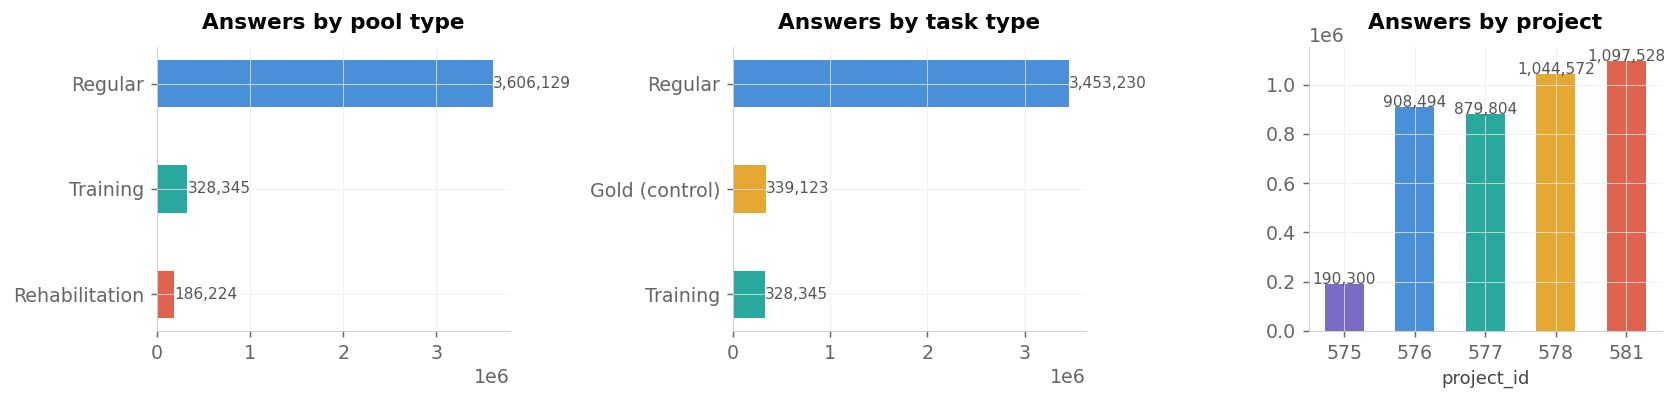

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))

# ── a) pool type ──────────────────────────────────────────────────────
pt = df["pool_label"].value_counts()
bars = axes[0].barh(pt.index, pt.values, height=0.45,
                    color=[POOL_C[k] for k in [0,3,1]])
bar_labels(axes[0], bars, horizontal=True)
axes[0].set_title("Answers by pool type")
axes[0].invert_yaxis(); despine(axes[0])

# ── b) task type ──────────────────────────────────────────────────────
tt = df["task_label"].value_counts()
bars = axes[1].barh(tt.index, tt.values, height=0.45,
                    color=[C["blue"], C["amber"], C["teal"]])
bar_labels(axes[1], bars, horizontal=True)
axes[1].set_title("Answers by task type")
axes[1].invert_yaxis(); despine(axes[1])

# ── c) project ────────────────────────────────────────────────────────
pj = df["project_id"].value_counts().sort_index()
bars = axes[2].bar([str(p) for p in pj.index], pj.values, width=0.55,
                   color=[PROJECT_C[p] for p in pj.index])
bar_labels(axes[2], bars)
axes[2].set_title("Answers by project")
axes[2].set_xlabel("project_id"); despine(axes[2])

plt.tight_layout()
plt.show()

In [36]:
# key numbers
reg = df[df["pool_type"] == 0]
gold_in_reg = reg[reg["task_type"] == 1]
print(f"Gold-task share inside regular pools: {len(gold_in_reg)/len(reg)*100:.1f}%")
print(f"Overlap distribution (regular pool):")
print(reg["overlap"].value_counts().sort_index().to_frame("count"))

Gold-task share inside regular pools: 4.2%
Overlap distribution (regular pool):
           count
overlap         
1           8050
2        2518619
3         949478
5         129982


## 4 · Page structure and timing model

A **page** is the unit shown to the worker at once. The `page_duration_sec` column captures **total page time** — if a page contains 3 tasks, that duration covers all three. We approximate per-task time as `page_duration / tasks_per_page`.

In [37]:
print("Tasks per page by pool type:")
print(pd.crosstab(df["pool_label"], df["tasks_per_page"]))

Tasks per page by pool type:
tasks_per_page       1       2        3
pool_label                             
Regular         423420       0  3182709
Rehabilitation       0  186224        0
Training        328108       0      237


**Structure:**
- Regular pool: mostly 3 tasks/page (3.18 M rows, 88 %), plus 423 K single-task pages.
- Rehabilitation: always 2 tasks/page (186 K rows).
- Training: always 1 task/page (328 K rows, with 237 minor exceptions).

Raw `page_duration_sec` is **not comparable** across pool types without dividing by `tasks_per_page`.

## 5 · Per-project breakdown

In [38]:
ps = df.groupby("project_id").agg(
    answers  = ("task_id", "size"),
    workers  = ("ozon_id", "nunique"),
    tasks    = ("task_id", "nunique"),
    pools    = ("pool_id", "nunique"),
    med_price = ("price", "median"),
    gold_pct  = ("task_type", lambda x: (x == 1).mean() * 100),
    skip_rate = ("skipped", "mean"),
).round(2)
ps

,answers,workers,tasks,pools,med_price,gold_pct,skip_rate
project_id,,,,,,,
575,190300,798,66342,594,50.0,8.56,0.02
576,908494,4158,321414,854,50.0,7.28,0.03
577,879804,11167,243834,899,70.0,10.52,0.04
578,1044572,498,389364,874,60.0,6.70,0.04
581,1097528,5363,341317,861,70.0,8.58,0.05


In [39]:
# project × pool type
pt_proj = pd.crosstab(df["project_id"], df["pool_label"], normalize="index").round(3) * 100
pt_proj.columns.name = None
pt_proj.rename(columns=str).style.format("{:.1f}%")

,Regular,Rehabilitation,Training
project_id,,,
575,94.5%,5.4%,0.1%
576,89.2%,3.9%,6.8%
577,72.8%,7.3%,19.9%
578,97.3%,2.5%,0.2%
581,87.3%,4.5%,8.1%


**Observations:**
- Project 577 has the steepest onboarding (10.5 % gold share, 11 167 workers — the widest workforce).
- Project 578 is the largest by volume (1.04 M answers) but has only 498 workers — a small, specialised team.
- Project 575 is the smallest (190 K answers, 798 workers) with the highest gold-task share (8.6 %).

### 5.1 · Worker overlap between projects

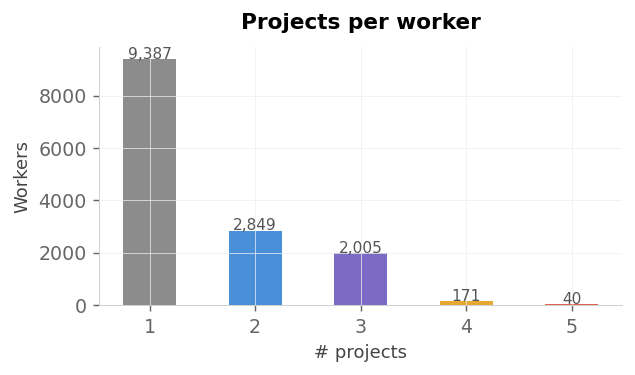

Workers in 2+ projects: 5,065 (35.0%) — enables cross-project analysis


In [40]:
wp = df.groupby("ozon_id")["project_id"].nunique()
ov = wp.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(ov.index.astype(str), ov.values, width=0.5,
              color=[C["gray"], C["blue"], C["purple"], C["amber"], C["coral"]][:len(ov)])
bar_labels(ax, bars)
ax.set_xlabel("# projects"); ax.set_ylabel("Workers"); ax.set_title("Projects per worker")
despine(ax); plt.tight_layout(); plt.show()

multi = wp[wp >= 2].count()
print(f"Workers in 2+ projects: {multi:,} ({multi/len(wp)*100:.1f}%) — enables cross-project analysis")

## 6 · Worker activity distribution

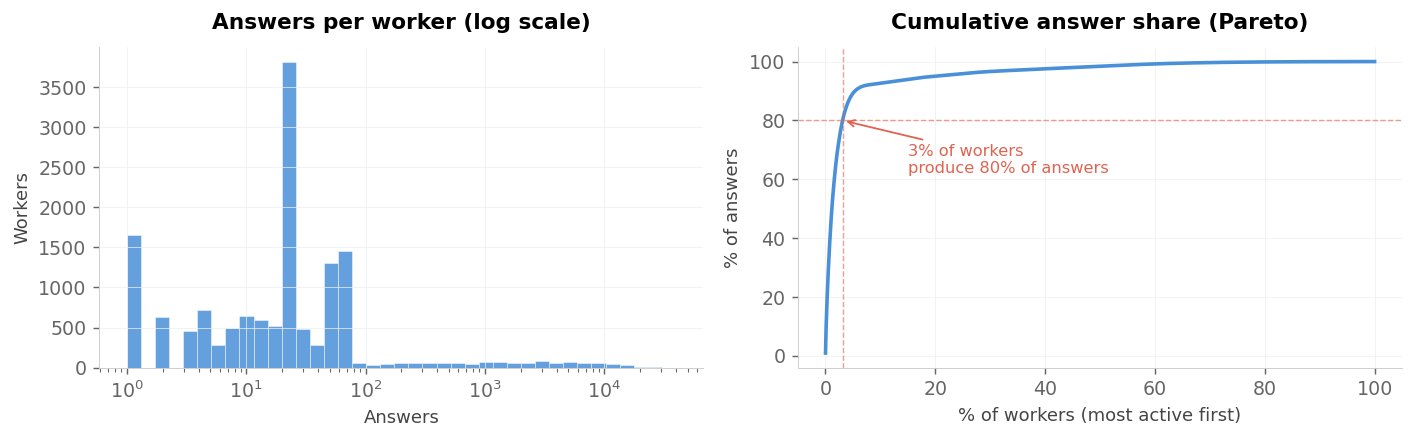

Median: 25  ·  Mean: 285.1  ·  Max: 39,824
One-shot workers (1 answer): 1,653 (11.4%)
Power workers (≥100): 1,082 (7.5%)


In [41]:
apw = df.groupby("ozon_id").size().rename("n")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# a) histogram (log)
axes[0].hist(apw, bins=np.logspace(0, np.log10(apw.max()), 40),
             color=C["blue"], alpha=0.85, edgecolor="white", linewidth=0.3)
axes[0].set_xscale("log")
axes[0].set_title("Answers per worker (log scale)")
axes[0].set_xlabel("Answers"); axes[0].set_ylabel("Workers"); despine(axes[0])

# b) Pareto / CDF
s = np.sort(apw.values)[::-1]
cum = np.cumsum(s) / s.sum() * 100
x   = np.arange(1, len(s)+1) / len(s) * 100
axes[1].plot(x, cum, color=C["blue"], linewidth=2)
axes[1].axhline(80, color=C["coral"], ls="--", lw=0.8, alpha=0.6)
idx80 = np.searchsorted(cum, 80)
pct80 = x[idx80]
axes[1].axvline(pct80, color=C["coral"], ls="--", lw=0.8, alpha=0.6)
axes[1].annotate(f"{pct80:.0f}% of workers\nproduce 80% of answers",
                 xy=(pct80, 80), fontsize=9, color=C["coral"],
                 xytext=(pct80+12, 62),
                 arrowprops=dict(arrowstyle="->", color=C["coral"], lw=1))
axes[1].set_title("Cumulative answer share (Pareto)")
axes[1].set_xlabel("% of workers (most active first)")
axes[1].set_ylabel("% of answers"); despine(axes[1])

plt.tight_layout(); plt.show()

print(f"Median: {apw.median():.0f}  ·  Mean: {apw.mean():.1f}  ·  Max: {apw.max():,}")
print(f"One-shot workers (1 answer): {(apw==1).sum():,} ({(apw==1).mean()*100:.1f}%)")
print(f"Power workers (≥100): {(apw>=100).sum():,} ({(apw>=100).mean()*100:.1f}%)")

**Long-tail, but less extreme than small samples suggest.** On the full dataset the median worker contributes 25 answers and only 11.4 % are one-shot. Still, the distribution is heavily skewed: 7.5 % of workers (1 082 "power workers" with 100+ answers) produce the bulk of volume. 35 % of workers participate in 2+ projects, enabling cross-project quality comparisons.

### 6.1 · Worker lifetime

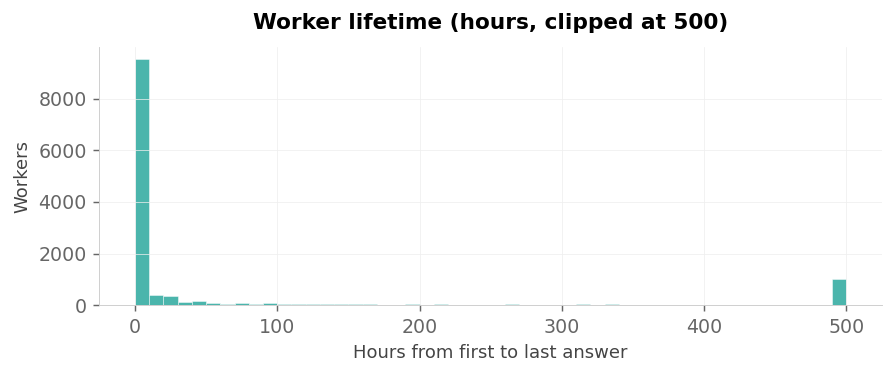

One-shot workers: 1,653 / 14,452
Median lifetime (workers with ≥2 answers): 0.3 h
Max: 719 h (30 days)


In [42]:
wl = df.groupby("ozon_id").agg(t0=("created_at","min"), t1=("created_at","max"), n=("task_id","count"))
wl["hours"] = (wl["t1"] - wl["t0"]).dt.total_seconds() / 3600

active = wl[wl["n"] > 1]

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(active["hours"].clip(upper=500), bins=50, color=C["teal"], alpha=0.85,
        edgecolor="white", linewidth=0.3)
ax.set_title("Worker lifetime (hours, clipped at 500)")
ax.set_xlabel("Hours from first to last answer"); ax.set_ylabel("Workers")
despine(ax); plt.tight_layout(); plt.show()

print(f"One-shot workers: {(wl['n']==1).sum():,} / {len(wl):,}")
print(f"Median lifetime (workers with ≥2 answers): {active['hours'].median():.1f} h")
print(f"Max: {wl['hours'].max():.0f} h ({wl['hours'].max()/24:.0f} days)")

## 7 · Response time analysis

Since timing is at the page level, we use **per-task time** = `page_duration / tasks_per_page` for fair comparison across pool types.

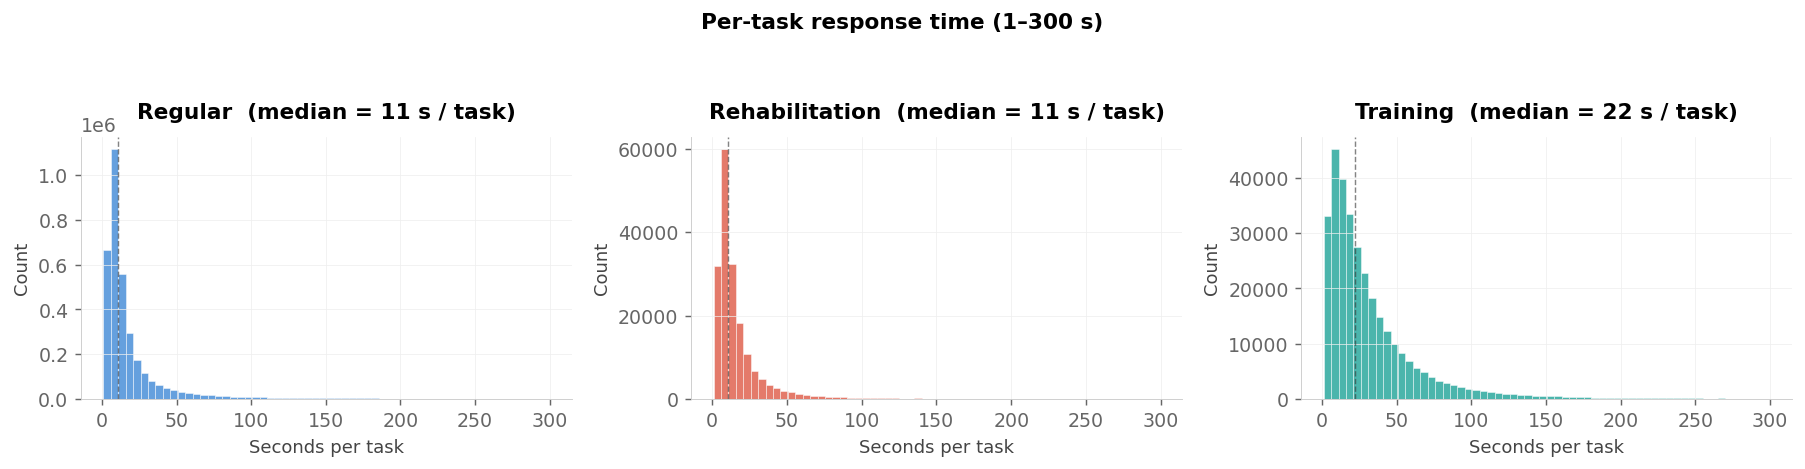

Percentiles — regular pool, per-task seconds:
  P 5:      4.6
  P25:      6.8
  P50:     11.1
  P75:     22.8
  P90:     70.4
  P95:    231.3
  P99:    642.6


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for i, (pt, name) in enumerate(POOL_MAP.items()):
    d = df.loc[(df["pool_type"]==pt) & df["per_task_sec"].between(1, 300), "per_task_sec"]
    axes[i].hist(d, bins=60, color=POOL_C[pt], alpha=0.85, edgecolor="white", lw=0.3)
    med = d.median()
    axes[i].axvline(med, color="#333", ls="--", lw=0.8, alpha=0.6)
    axes[i].set_title(f"{name}  (median = {med:.0f} s / task)")
    axes[i].set_xlabel("Seconds per task"); axes[i].set_ylabel("Count")
    despine(axes[i])

plt.suptitle("Per-task response time (1–300 s)", fontsize=12, fontweight=600, y=1.02)
plt.tight_layout(); plt.show()

print("Percentiles — regular pool, per-task seconds:")
d0 = df[(df["pool_type"]==0) & df["per_task_sec"].between(0.5, 1e6)]["per_task_sec"]
for p in [5, 25, 50, 75, 90, 95, 99]:
    print(f"  P{p:>2}: {d0.quantile(p/100):>8.1f}")

**Key points:**
- Median per-task time: **11.1 s** (regular pool), with P5 = 4.6 s and P95 = 231 s.
- The long tail beyond P95 reflects idle browser tabs rather than genuine task effort.
- Rehabilitation and training pools show similar normalised medians once we account for different tasks-per-page (2 for rehab, 1 for training).

## 8 · Answer distribution and correctness

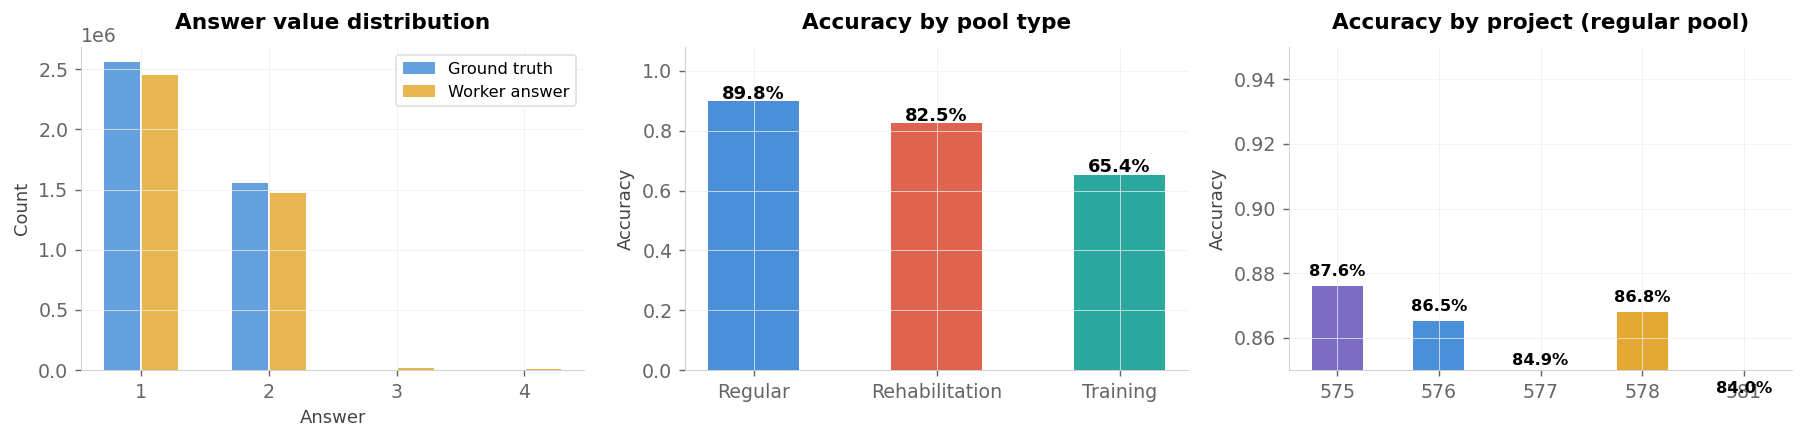

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

# a) answer value distribution
for col, lbl, clr, dx in [("task_ans","Ground truth",C["blue"],-0.15),
                            ("user_ans","Worker answer",C["amber"],0.15)]:
    vc = df[col].dropna().value_counts().sort_index()
    axes[0].bar(vc.index + dx, vc.values, width=0.28, color=clr, label=lbl, alpha=0.85)
axes[0].set_xticks([1,2,3,4]); axes[0].legend(fontsize=9)
axes[0].set_title("Answer value distribution"); axes[0].set_xlabel("Answer"); axes[0].set_ylabel("Count")
despine(axes[0])

# b) accuracy by pool type
pool_acc = {}
for pt, nm in POOL_MAP.items():
    s = df[(df["pool_type"]==pt) & df["user_ans"].notna() & df["task_ans"].notna()]
    pool_acc[nm] = s["correct"].mean()
bars = axes[1].bar(pool_acc.keys(), pool_acc.values(), width=0.5,
                   color=[POOL_C[k] for k in POOL_MAP])
for b, v in zip(bars, pool_acc.values()):
    axes[1].text(b.get_x()+b.get_width()/2, v+0.008, f"{v:.1%}",
                 ha="center", fontsize=10, fontweight=600)
axes[1].set_title("Accuracy by pool type"); axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.08); despine(axes[1])

# c) accuracy by project (regular pool)
proj_acc = (df[(df["pool_type"]==0) & df["correct"].notna()]
            .groupby("project_id")["correct"].mean().sort_index())
bars = axes[2].bar([str(p) for p in proj_acc.index], proj_acc.values, width=0.5,
                   color=[PROJECT_C[p] for p in proj_acc.index])
for b, v in zip(bars, proj_acc.values):
    axes[2].text(b.get_x()+b.get_width()/2, v+0.003, f"{v:.1%}",
                 ha="center", fontsize=9, fontweight=600)
axes[2].set_title("Accuracy by project (regular pool)"); axes[2].set_ylabel("Accuracy")
axes[2].set_ylim(0.85, 0.95); despine(axes[2])

plt.tight_layout(); plt.show()

**Observations:**
- Answers are overwhelmingly binary (values 1 and 2); classes 3 and 4 are extremely rare.
- Regular-pool accuracy: **~89 %** — a solid baseline for aggregation models to improve upon.
- Rehabilitation accuracy: **~82 %** — expected, since workers enter rehab after errors.
- Training accuracy: **~66 %** — mistakes are part of the learning process.
- Cross-project accuracy in the regular pool varies from ~89 % to ~91 %.

### 8.1 · Class balance per project

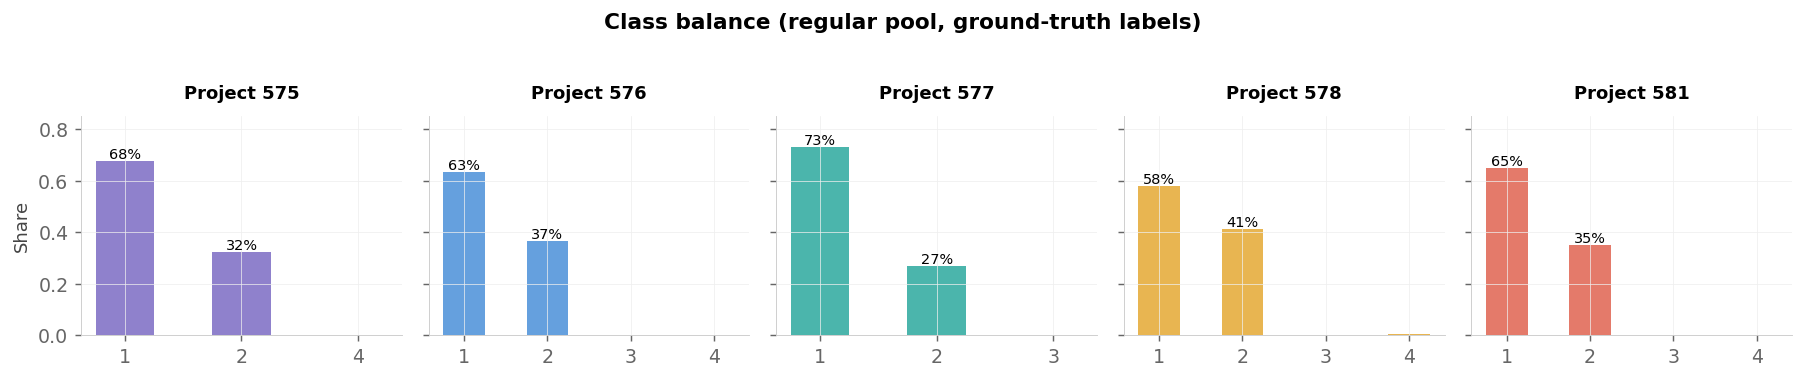

In [45]:
fig, axes = plt.subplots(1, 5, figsize=(14, 2.8), sharey=True)

for ax, pid in zip(axes, sorted(df["project_id"].unique())):
    s = df[(df["project_id"]==pid) & df["task_ans"].notna() & (df["pool_type"]==0)]
    vc = s["task_ans"].value_counts(normalize=True).sort_index()
    bars = ax.bar(vc.index.astype(int).astype(str), vc.values,
                  color=PROJECT_C[pid], width=0.5, alpha=0.85)
    for b, v in zip(bars, vc.values):
        if v > 0.01:
            ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.0%}",
                    ha="center", fontsize=8)
    ax.set_title(f"Project {pid}", fontsize=10)
    ax.set_ylim(0, 0.85); despine(ax)

axes[0].set_ylabel("Share")
plt.suptitle("Class balance (regular pool, ground-truth labels)", fontsize=12, fontweight=600, y=1.03)
plt.tight_layout(); plt.show()

**Note on baseline accuracy.** All projects skew toward label 1 (58–73 %). A trivial "always predict 1" classifier would achieve 58–73 % accuracy — important context when evaluating worker performance. Project 577 has the strongest imbalance (73 % class 1), project 578 the weakest (58 %).

### 8.2 · Error analysis — confusion matrix

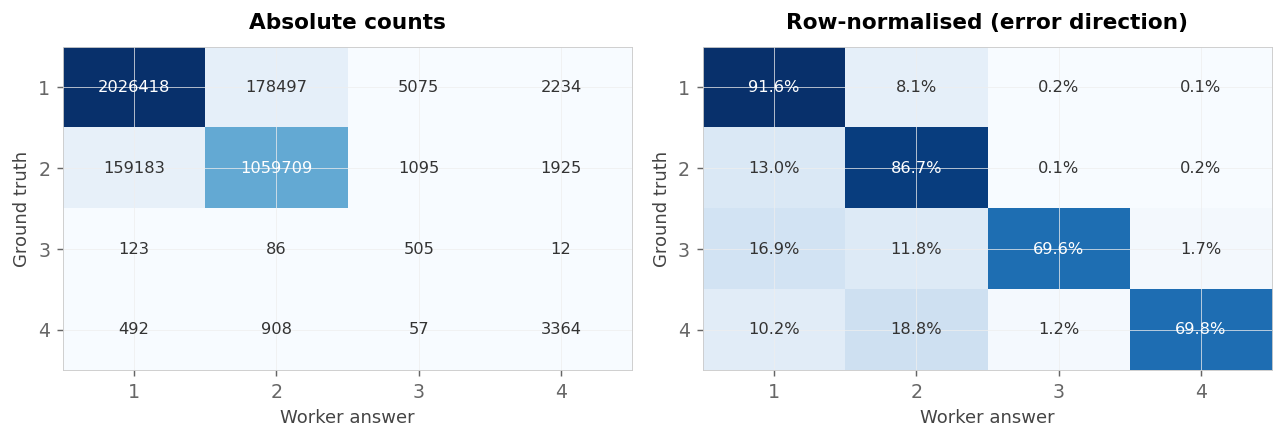

In [46]:
main = df[(df["pool_type"]==0) & df["user_ans"].notna() & df["task_ans"].notna()]

conf     = pd.crosstab(main["task_ans"], main["user_ans"], rownames=["truth"], colnames=["worker"])
conf_pct = pd.crosstab(main["task_ans"], main["user_ans"], normalize="index").round(3)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax, data, title, fmt in [(axes[0], conf, "Absolute counts", "d"),
                               (axes[1], conf_pct, "Row-normalised (error direction)", ".1%")]:
    im = ax.imshow(data.values, cmap="Blues", aspect="auto")
    ax.set_xticks(range(len(data.columns))); ax.set_xticklabels(data.columns.astype(int))
    ax.set_yticks(range(len(data.index)));   ax.set_yticklabels(data.index.astype(int))
    ax.set_xlabel("Worker answer"); ax.set_ylabel("Ground truth"); ax.set_title(title)
    for i in range(len(data)):
        for j in range(len(data.columns)):
            v = data.iloc[i,j]
            txt = f"{v:{fmt}}" if isinstance(v, (int, np.integer)) else f"{v:.1%}"
            ax.text(j, i, txt, ha="center", va="center",
                    color="white" if data.values[i,j] > data.values.max()*0.5 else "#333", fontsize=9)

plt.tight_layout(); plt.show()

**Almost all errors are 1 ↔ 2 swaps** (96–98 % of mistakes). The task is effectively binary classification. Classes 3 and 4 barely register in the confusion matrix. For modelling purposes, focusing on the 1-vs-2 decision boundary captures nearly all the signal.

### 8.3 · Gold-task accuracy per worker

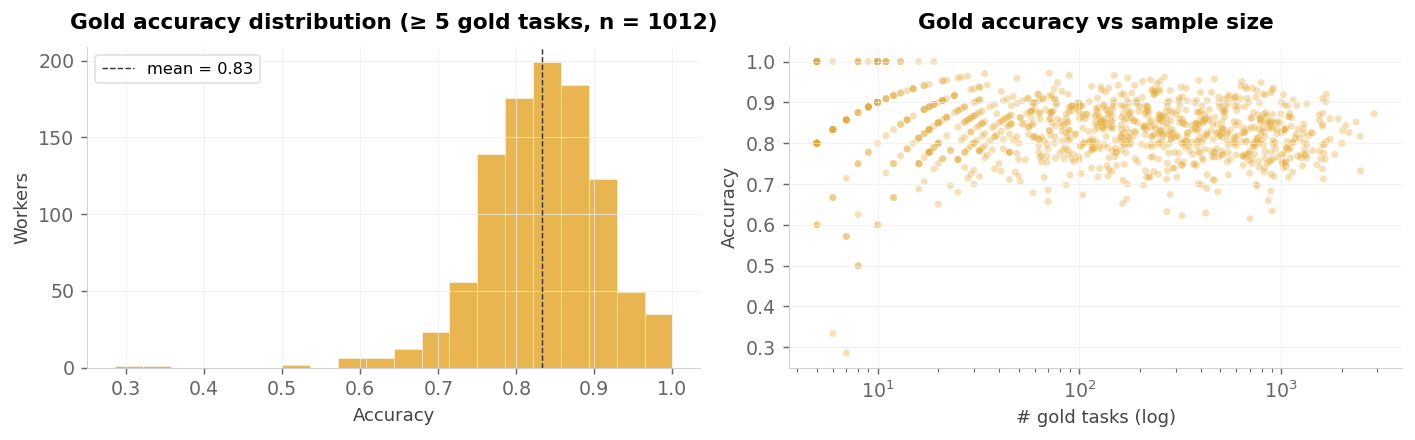

Gold accuracy — mean: 0.833, std: 0.077, range: [0.29, 1.00]


In [47]:
gold = df[(df["task_type"]==1) & df["user_ans"].notna() & df["task_ans"].notna()].copy()
gold["correct"] = (gold["user_ans"] == gold["task_ans"]).astype(int)

wg = gold.groupby("ozon_id")["correct"].agg(["mean","count"])
wg.columns = ["gold_acc", "n_gold"]
rel = wg[wg["n_gold"] >= 5]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].hist(rel["gold_acc"], bins=20, color=C["amber"], alpha=0.85,
             edgecolor="white", lw=0.3)
axes[0].axvline(rel["gold_acc"].mean(), color="#333", ls="--", lw=0.8,
                label=f"mean = {rel['gold_acc'].mean():.2f}")
axes[0].set_title(f"Gold accuracy distribution (≥ 5 gold tasks, n = {len(rel)})")
axes[0].set_xlabel("Accuracy"); axes[0].set_ylabel("Workers"); axes[0].legend()
despine(axes[0])

axes[1].scatter(rel["n_gold"], rel["gold_acc"], alpha=0.35, s=15,
                color=C["amber"], edgecolors="none")
axes[1].set_title("Gold accuracy vs sample size")
axes[1].set_xlabel("# gold tasks (log)"); axes[1].set_ylabel("Accuracy")
axes[1].set_xscale("log"); despine(axes[1])

plt.tight_layout(); plt.show()

print(f"Gold accuracy — mean: {rel['gold_acc'].mean():.3f}, "
      f"std: {rel['gold_acc'].std():.3f}, "
      f"range: [{rel['gold_acc'].min():.2f}, {rel['gold_acc'].max():.2f}]")

## 9 · Pricing and its link to quality

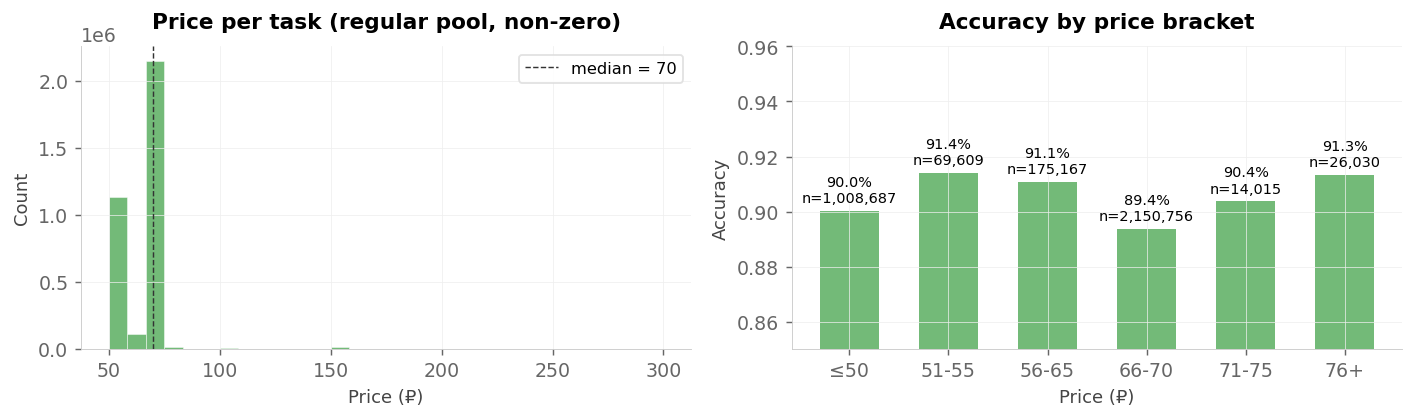

Zero-price tasks in regular pool: 161,864
  task_type=0 (regular): 156,361
  task_type=1 (gold):    5,503


In [48]:
reg = df[df["pool_type"] == 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# a) price distribution
nz = reg[reg["price"] > 0]["price"]
axes[0].hist(nz, bins=30, color=C["green"], alpha=0.85, edgecolor="white", lw=0.3)
axes[0].axvline(nz.median(), color="#333", ls="--", lw=0.8,
                label=f"median = {nz.median():.0f}")
axes[0].set_title("Price per task (regular pool, non-zero)")
axes[0].set_xlabel("Price (₽)"); axes[0].set_ylabel("Count")
axes[0].legend(); despine(axes[0])

# b) accuracy by price bracket
scored = reg[reg["correct"].notna() & (reg["price"] > 0)].copy()
scored["p_bin"] = pd.cut(scored["price"], bins=[0,50,55,65,70,75,250],
                         labels=["≤50","51-55","56-65","66-70","71-75","76+"])
abp = scored.groupby("p_bin", observed=True)["correct"].agg(["mean","count"])

bars = axes[1].bar(abp.index.astype(str), abp["mean"],
                   color=C["green"], alpha=0.85, width=0.6)
for b, (_, r) in zip(bars, abp.iterrows()):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
                 f"{r['mean']:.1%}\nn={r['count']:,.0f}", ha="center", fontsize=8)
axes[1].set_title("Accuracy by price bracket")
axes[1].set_xlabel("Price (₽)"); axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0.85, 0.96); despine(axes[1])

plt.tight_layout(); plt.show()

free = reg[reg["price"] == 0]
print(f"Zero-price tasks in regular pool: {len(free):,}")
print(f"  task_type=0 (regular): {(free['task_type']==0).sum():,}")
print(f"  task_type=1 (gold):    {(free['task_type']==1).sum():,}")

**Findings:**
- Two dominant price points: **50 ₽** and **66–70 ₽**, visible as sharp histogram spikes.
- Higher-priced tasks correlate with slightly higher accuracy, though causality is unclear (self-selection vs task difficulty).
- **161 864 zero-price tasks** exist in regular pools (156 K regular + 5.5 K gold) — likely internal test or bonus batches.

## 10 · Temporal patterns

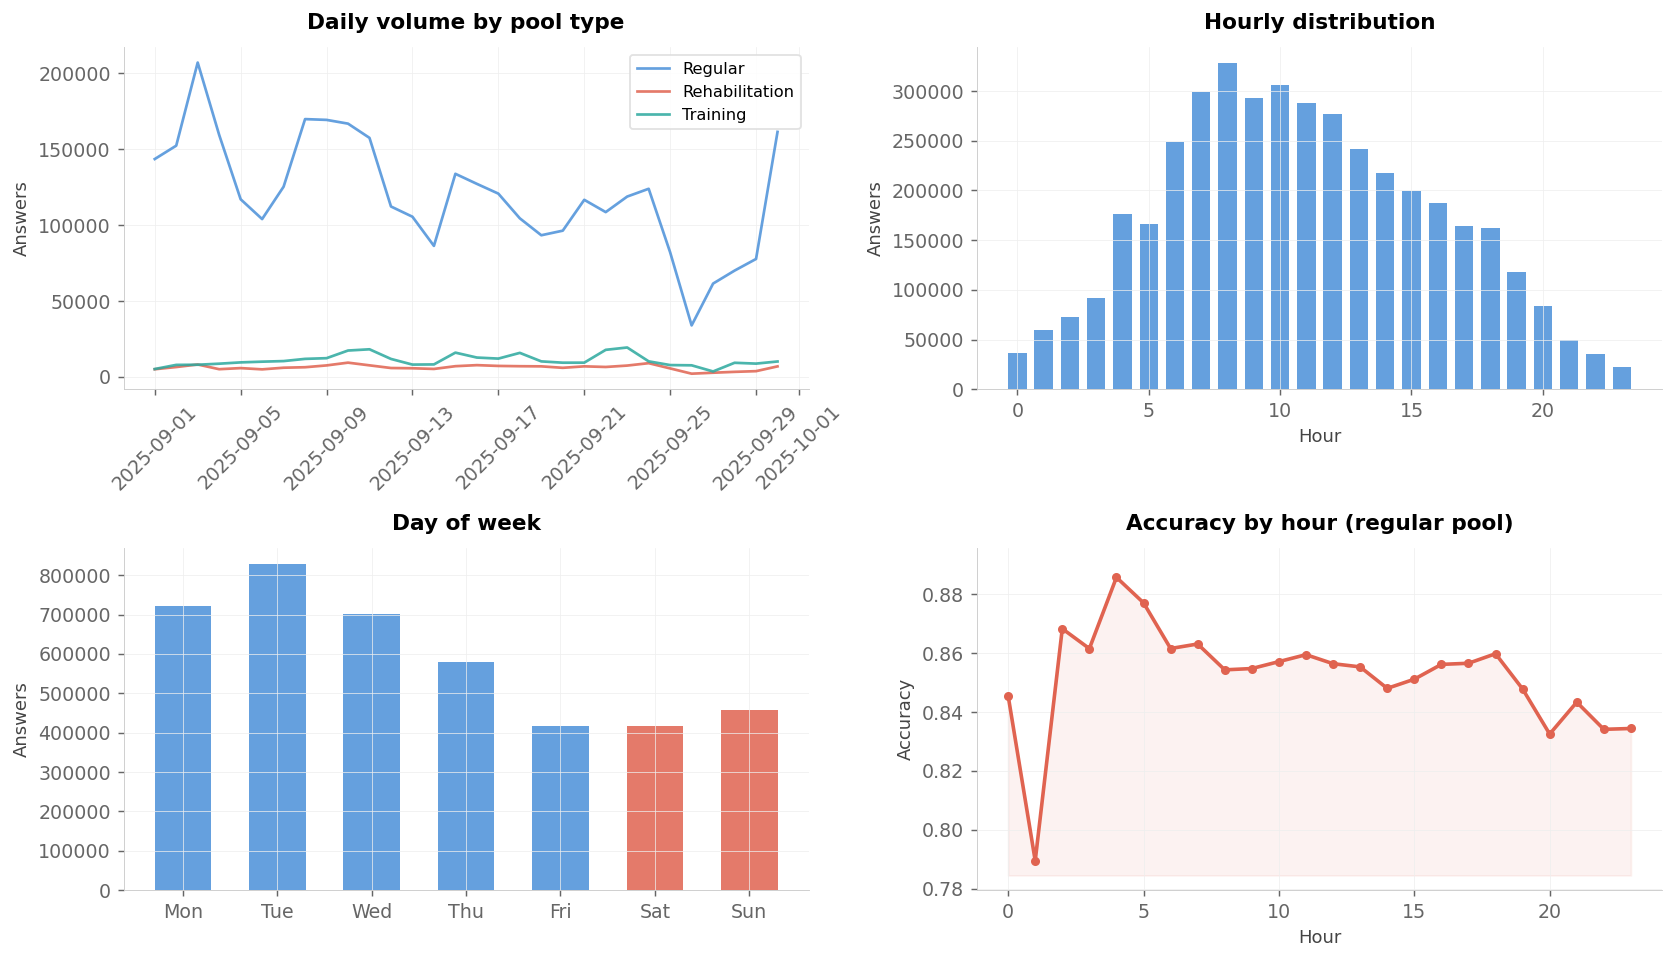

In [49]:
df["date"] = df["created_at"].dt.date
df["hour"] = df["created_at"].dt.hour
df["dow"]  = df["created_at"].dt.dayofweek

fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))

# a) daily volume by pool
daily = df.groupby(["date","pool_type"]).size().unstack(fill_value=0)
for pt, nm in POOL_MAP.items():
    if pt in daily.columns:
        axes[0,0].plot(daily.index, daily[pt], label=nm,
                       color=POOL_C[pt], lw=1.5, alpha=0.85)
axes[0,0].set_title("Daily volume by pool type"); axes[0,0].legend()
axes[0,0].set_ylabel("Answers"); axes[0,0].tick_params(axis="x", rotation=45); despine(axes[0,0])

# b) hourly
hr = df.groupby("hour").size()
axes[0,1].bar(hr.index, hr.values, color=C["blue"], alpha=0.85, width=0.7)
axes[0,1].set_title("Hourly distribution"); axes[0,1].set_xlabel("Hour"); axes[0,1].set_ylabel("Answers")
despine(axes[0,1])

# c) day of week
dow_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_c = df["dow"].value_counts().sort_index()
bars = axes[1,0].bar(dow_names, dow_c.values, width=0.6,
                     color=[C["blue"] if d<5 else C["coral"] for d in range(7)], alpha=0.85)
axes[1,0].set_title("Day of week"); axes[1,0].set_ylabel("Answers"); despine(axes[1,0])

# d) accuracy by hour
ha = (df[(df["pool_type"]==0) & df["correct"].notna()]
      .groupby("hour")["correct"].mean())
axes[1,1].plot(ha.index, ha.values, color=C["coral"], lw=2, marker="o", ms=4)
axes[1,1].fill_between(ha.index, ha.values, ha.min()-0.005, alpha=0.08, color=C["coral"])
axes[1,1].set_title("Accuracy by hour (regular pool)")
axes[1,1].set_xlabel("Hour"); axes[1,1].set_ylabel("Accuracy")
axes[1,1].set_ylim(ha.min()-0.01, ha.max()+0.01); despine(axes[1,1])

plt.tight_layout(); plt.show()

**Temporal insights:**
- **Peak hours**: 06:00–14:00 (Moscow time assumed) — morning and early afternoon dominate.
- **Weekend dip**: Sat–Sun volume drops ~30 %, but work doesn't stop — this is a flexible side job for many.
- **Night-owl bonus**: Accuracy peaks in early-morning hours (~92 %), possibly a more focused, self-selected audience.
- **Evening slump**: Accuracy dips around 20:00 (~87 %), consistent with end-of-day fatigue.

## 11 · Speed vs quality

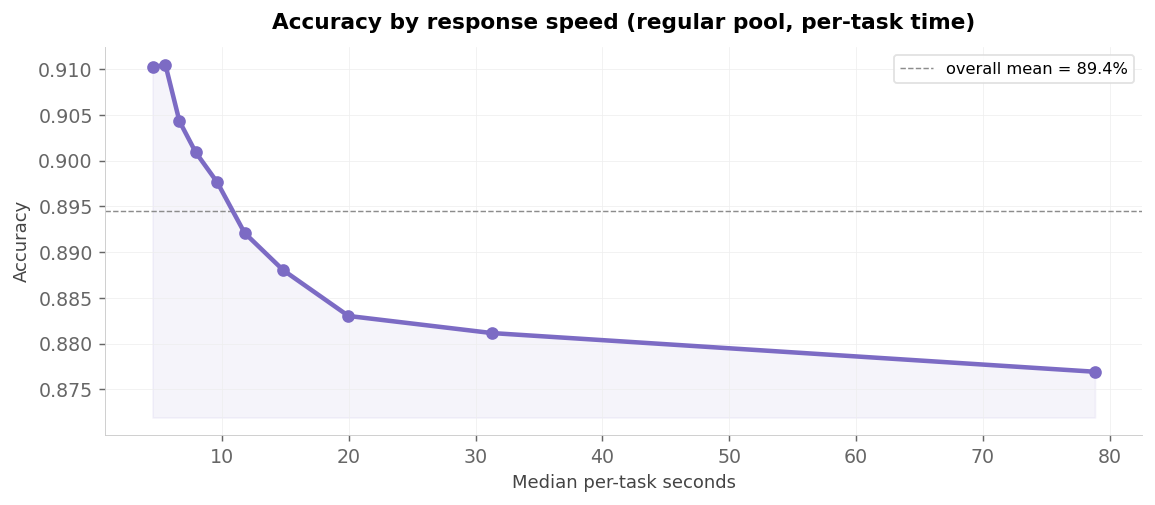

Accuracy by speed decile:
  ~    5 s/task  →  91.0%  (n = 344,353)
  ~    6 s/task  →  91.1%  (n = 344,351)
  ~    7 s/task  →  90.4%  (n = 344,352)
  ~    8 s/task  →  90.1%  (n = 344,352)
  ~   10 s/task  →  89.8%  (n = 344,352)
  ~   12 s/task  →  89.2%  (n = 344,351)
  ~   15 s/task  →  88.8%  (n = 344,352)
  ~   20 s/task  →  88.3%  (n = 344,352)
  ~   31 s/task  →  88.1%  (n = 344,352)
  ~   79 s/task  →  87.7%  (n = 344,352)


In [50]:
scored = df[(df["pool_type"]==0) & df["correct"].notna()
             & df["per_task_sec"].between(1, 300)].copy()

scored["speed_q"] = pd.qcut(scored["per_task_sec"], 10, duplicates="drop")
sa = scored.groupby("speed_q", observed=True).agg(
    accuracy   = ("correct", "mean"),
    count      = ("correct", "count"),
    median_sec = ("per_task_sec", "median"))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sa["median_sec"], sa["accuracy"], color=C["purple"], lw=2.5, marker="o", ms=6, zorder=5)
ax.fill_between(sa["median_sec"], sa["accuracy"],
                sa["accuracy"].min()-0.005, alpha=0.07, color=C["purple"])
ax.axhline(scored["correct"].mean(), color=C["gray"], ls="--", lw=0.8,
           label=f"overall mean = {scored['correct'].mean():.1%}")
ax.set_title("Accuracy by response speed (regular pool, per-task time)")
ax.set_xlabel("Median per-task seconds"); ax.set_ylabel("Accuracy")
ax.legend(); despine(ax); plt.tight_layout(); plt.show()

print("Accuracy by speed decile:")
for _, r in sa.iterrows():
    print(f"  ~{r['median_sec']:>5.0f} s/task  →  {r['accuracy']:.1%}  (n = {r['count']:,.0f})")

**Counter-intuitive result: faster workers are more accurate.** At ~5 s/task accuracy is 91.0 %; at ~79 s/task it drops to 87.7 %. This most likely reflects **task difficulty** — easy tasks get answered quickly and correctly, hard tasks take longer and produce more errors. A proper analysis must control for task difficulty, e.g. by comparing workers on the *same* task.

## 12 · Task difficulty

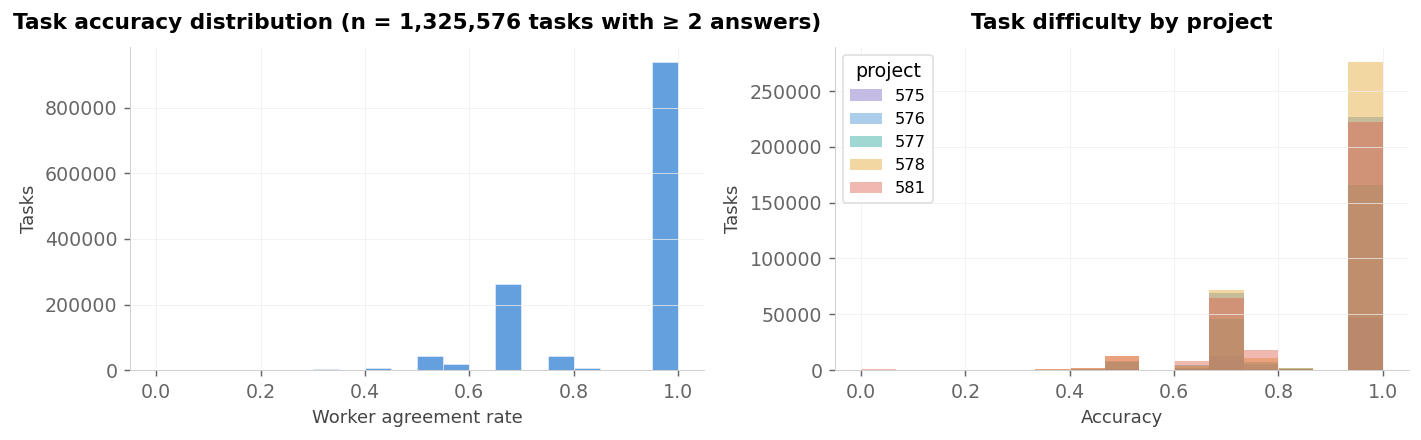

Unanimous agreement (100%): 70.7% of tasks
Contested tasks (<50%):     0.9% of tasks


In [51]:
tq = (df[(df["pool_type"]==0) & (df["task_type"]==0) & df["correct"].notna()]
      .groupby("task_id")
      .agg(n=("correct","count"), accuracy=("correct","mean"), project=("project_id","first")))
tq_multi = tq[tq["n"] >= 2]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].hist(tq_multi["accuracy"], bins=20, color=C["blue"], alpha=0.85,
             edgecolor="white", lw=0.3)
axes[0].set_title(f"Task accuracy distribution (n = {len(tq_multi):,} tasks with ≥ 2 answers)")
axes[0].set_xlabel("Worker agreement rate"); axes[0].set_ylabel("Tasks"); despine(axes[0])

for pid in sorted(tq_multi["project"].unique()):
    s = tq_multi[tq_multi["project"]==pid]
    axes[1].hist(s["accuracy"], bins=15, alpha=0.45, label=str(pid),
                 color=PROJECT_C.get(pid, C["gray"]))
axes[1].set_title("Task difficulty by project")
axes[1].set_xlabel("Accuracy"); axes[1].set_ylabel("Tasks")
axes[1].legend(title="project"); despine(axes[1])

plt.tight_layout(); plt.show()

unanimous = (tq_multi["accuracy"] == 1.0).mean() * 100
hard      = (tq_multi["accuracy"] < 0.5).mean() * 100
print(f"Unanimous agreement (100%): {unanimous:.1f}% of tasks")
print(f"Contested tasks (<50%):     {hard:.1f}% of tasks")

**70.7 % of tasks are unanimous** — all workers agree. Only 0.9 % of tasks are truly contested (< 50 % accuracy). The aggregation challenge lies in the ~29 % of borderline tasks where at least one out of 2–3 workers disagrees.

## 13 · Skip behaviour

In [52]:
print("Skip rate by pool type:")
for pt, nm in POOL_MAP.items():
    r = df[df["pool_type"]==pt]["skipped"].mean()
    print(f"  {nm:18s}  {r:.2%}")

# do skippers have higher or lower accuracy?
skip_ids = df[(df["pool_type"]==0) & df["skipped"]]["ozon_id"].unique()
skip_acc = df[(df["ozon_id"].isin(skip_ids)) & (df["pool_type"]==0) & df["correct"].notna()]["correct"].mean()
no_skip_acc = df[(~df["ozon_id"].isin(skip_ids)) & (df["pool_type"]==0) & df["correct"].notna()]["correct"].mean()

print(f"\nWorkers who ever skipped: {len(skip_ids):,} ({len(skip_ids)/df['ozon_id'].nunique()*100:.1f}%)")
print(f"Accuracy — skippers:     {skip_acc:.4f}")
print(f"Accuracy — non-skippers: {no_skip_acc:.4f}")
print(f"Difference:              {skip_acc - no_skip_acc:+.4f}")

Skip rate by pool type:
  Regular             4.48%
  Rehabilitation      0.99%
  Training            0.00%

Workers who ever skipped: 1,296 (9.0%)
Accuracy — skippers:     0.8566
Accuracy — non-skippers: 0.8913
Difference:              -0.0347


**On the full dataset, skipping correlates with *lower* accuracy (−3.5 pp).** Only 9 % of workers (1 296) ever skip a task, and their overall accuracy is 85.7 % vs 89.1 % for non-skippers. Likely interpretation: frequent skipping signals lower engagement or encountering tasks outside one's competence, rather than conscientiousness.

Skip rates across pool types confirm structural expectations: training = 0 % (mandatory), rehabilitation = 1 % (motivated to complete), regular = 4.5 %.

## 14 · Overlap and accuracy

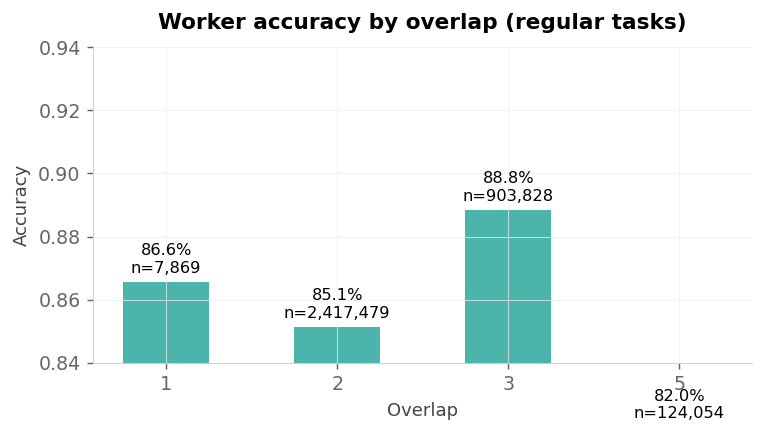

In [53]:
reg_scored = df[(df["pool_type"]==0) & (df["task_type"]==0) & df["correct"].notna()]
oa = reg_scored.groupby("overlap")["correct"].agg(["mean","count"])

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(oa.index.astype(str), oa["mean"], color=C["teal"], alpha=0.85, width=0.5)
for b, (_, r) in zip(bars, oa.iterrows()):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.003,
            f"{r['mean']:.1%}\nn={r['count']:,.0f}", ha="center", fontsize=9)
ax.set_title("Worker accuracy by overlap (regular tasks)")
ax.set_xlabel("Overlap"); ax.set_ylabel("Accuracy")
ax.set_ylim(0.84, 0.94); despine(ax); plt.tight_layout(); plt.show()

**Overlap = 3 yields the best per-worker accuracy; overlap = 5 yields the worst.** This is **selection bias**: the platform dynamically increases overlap for tasks that already showed disagreement at lower overlap. Overlap = 5 targets inherently ambiguous tasks, so workers answering them face harder items. Important context for any cost-quality simulation.

## 15 · Worker-level feature engineering

In [54]:
# ── base counts ───────────────────────────────────────────────────────
w = df.groupby("ozon_id").agg(
    n_answers   = ("task_id", "size"),
    n_projects  = ("project_id", "nunique"),
    n_pools     = ("pool_id", "nunique"),
    skip_rate   = ("skipped", "mean"),
).reset_index()

# ── timing (per-task seconds, filtered) ──────────────────────────────
dur = (df[df["per_task_sec"].between(1, 600)]
       .groupby("ozon_id")["per_task_sec"]
       .agg(med_duration="median", std_duration="std",
            p10_duration=lambda x: x.quantile(0.1),
            p90_duration=lambda x: x.quantile(0.9)))
w = w.merge(dur, on="ozon_id", how="left")

# ── gold accuracy ────────────────────────────────────────────────────
ga = (df[(df["task_type"]==1) & df["correct"].notna()]
      .groupby("ozon_id")["correct"]
      .agg(gold_acc="mean", n_gold="count"))
w = w.merge(ga, on="ozon_id", how="left")

# ── regular accuracy ─────────────────────────────────────────────────
ra = (df[(df["pool_type"]==0) & (df["task_type"]==0) & df["correct"].notna()]
      .groupby("ozon_id")["correct"]
      .agg(reg_acc="mean", n_regular="count"))
w = w.merge(ra, on="ozon_id", how="left")

# ── agreement rate ───────────────────────────────────────────────────
ag = (df[(df["pool_type"]==0) & (df["task_type"]==0) & df["correct"].notna()]
      .groupby("ozon_id")["correct"].mean().rename("agreement_rate"))
w = w.merge(ag, on="ozon_id", how="left")

# ── answer entropy ───────────────────────────────────────────────────
def entropy(s):
    p = s.value_counts(normalize=True)
    return -(p * np.log2(p.clip(lower=1e-10))).sum()
ent = df[df["user_ans"].notna()].groupby("ozon_id")["user_ans"].apply(entropy).rename("answer_entropy")
w = w.merge(ent, on="ozon_id", how="left")

# ── pool type flags ──────────────────────────────────────────────────
for pt, lbl in [(0,"has_regular"),(1,"has_rehab"),(3,"has_training")]:
    w[lbl] = w["ozon_id"].isin(df[df["pool_type"]==pt]["ozon_id"]).astype(int)

# ── lifetime ─────────────────────────────────────────────────────────
lt = df.groupby("ozon_id")["created_at"].agg(["min","max"])
lt["lifetime_h"] = (lt["max"] - lt["min"]).dt.total_seconds() / 3600
w = w.merge(lt[["lifetime_h"]], on="ozon_id", how="left")

# ── price ────────────────────────────────────────────────────────────
pr = df[df["pool_type"]==0].groupby("ozon_id")["price"].agg(mean_price="mean", max_price="max")
w = w.merge(pr, on="ozon_id", how="left")

print(f"Worker feature table: {w.shape[0]:,} workers × {w.shape[1]} features")
w.describe().round(3).T

Worker feature table: 14,452 workers × 21 features


,count,mean,std,min,25%,50%,75%,max
ozon_id,14452.0,1.043070e+08,6.092043e+07,186913.000,5.057931e+07,9.164303e+07,1.492274e+08,2.214094e+08
n_answers,14452.0,2.851300e+02,1.549014e+03,1.000,6.000000e+00,2.500000e+01,4.900000e+01,3.982400e+04
n_projects,14452.0,1.521000e+00,7.950000e-01,1.000,1.000000e+00,1.000000e+00,2.000000e+00,5.000000e+00
n_pools,14452.0,9.203000e+00,3.882900e+01,1.000,1.000000e+00,1.000000e+00,2.000000e+00,7.710000e+02
skip_rate,14452.0,1.000000e-02,5.600000e-02,0.000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
med_duration,13082.0,3.283700e+01,3.688000e+01,1.564,1.334200e+01,2.352000e+01,3.971400e+01,5.824670e+02
std_duration,12275.0,3.618700e+01,3.605800e+01,0.000,1.290400e+01,2.303900e+01,4.619700e+01,2.955190e+02
p10_duration,13082.0,1.882500e+01,2.836400e+01,1.125,6.414000e+00,1.132100e+01,2.024500e+01,5.824670e+02
p90_duration,13082.0,7.229300e+01,7.552400e+01,2.964,3.068800e+01,5.067400e+01,8.315700e+01,5.915860e+02
gold_acc,1210.0,7.870000e-01,1.720000e-01,0.000,7.510000e-01,8.120000e-01,8.670000e-01,1.000000e+00


### 15.1 · Feature correlation

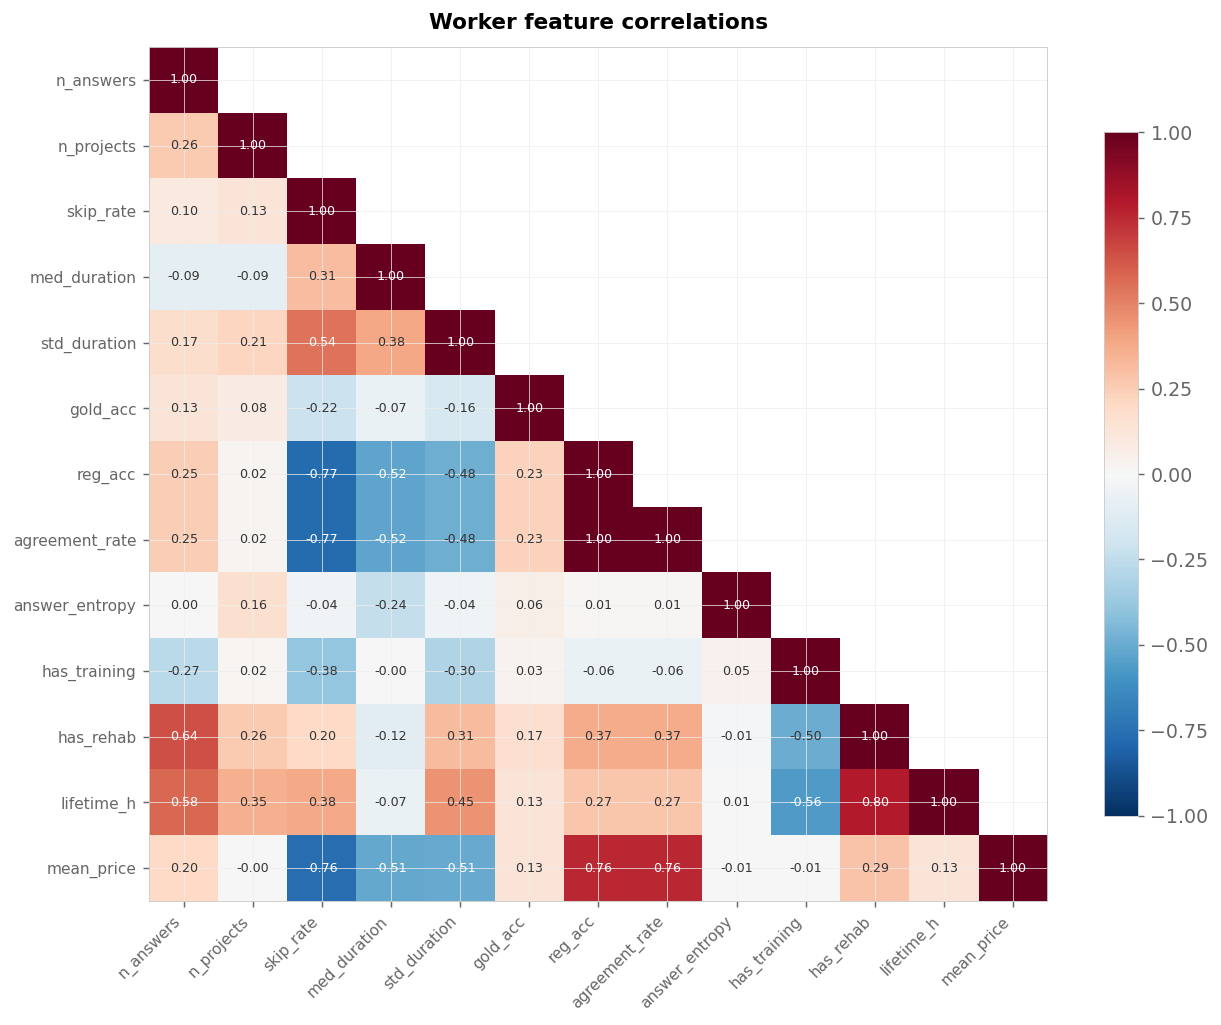

In [55]:
feats = ["n_answers","n_projects","skip_rate","med_duration","std_duration",
         "gold_acc","reg_acc","agreement_rate","answer_entropy",
         "has_training","has_rehab","lifetime_h","mean_price"]
corr = w[feats].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
im = ax.imshow(corr.where(~mask), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(feats))); ax.set_xticklabels(feats, rotation=45, ha="right", fontsize=8.5)
ax.set_yticks(range(len(feats))); ax.set_yticklabels(feats, fontsize=8.5)

for i in range(len(feats)):
    for j in range(len(feats)):
        if not mask[i,j] and not np.isnan(corr.iloc[i,j]):
            v = corr.iloc[i,j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=7, color="white" if abs(v)>0.5 else "#333")
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Worker feature correlations"); plt.tight_layout(); plt.show()

**Notable correlations:**
- `gold_acc` ↔ `agreement_rate` — strong positive: gold tasks reliably predict regular-task quality.
- `n_answers` ↔ `lifetime_h` — active workers stay longer on the platform.
- `has_rehab` — negatively correlated with accuracy (workers enter rehab *because* of errors).
- `answer_entropy` ↔ `n_answers` — more answers → more diverse response distribution, less trivial bias.

## 16 · Quality heterogeneity

Reliable workers (≥ 5 gold, ≥ 10 regular): 1010


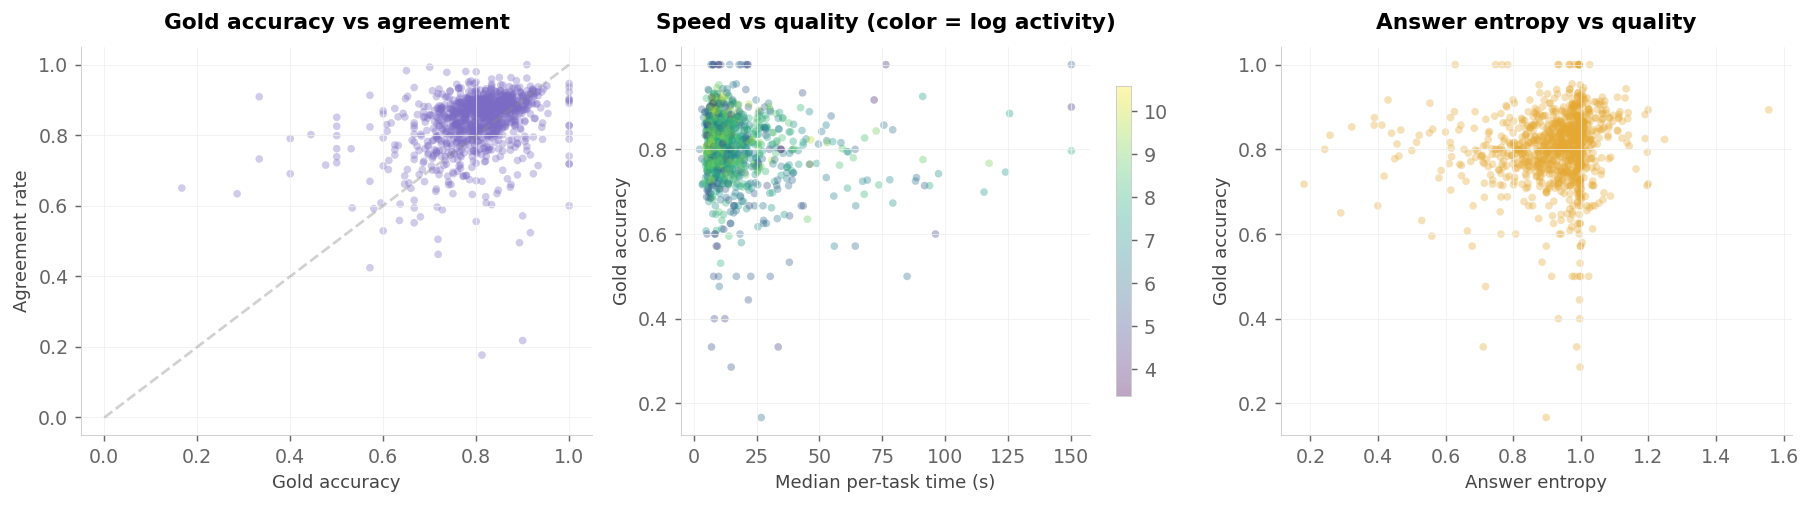

In [56]:
rw = w[(w["n_gold"] >= 5) & (w["n_regular"] >= 10)].copy()
print(f"Reliable workers (≥ 5 gold, ≥ 10 regular): {len(rw)}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# a) gold vs agreement
axes[0].scatter(rw["gold_acc"], rw["agreement_rate"], alpha=0.35, s=18,
                color=C["purple"], edgecolors="none")
axes[0].plot([0,1],[0,1], "--", color=C["gray"], alpha=0.4)
axes[0].set_xlabel("Gold accuracy"); axes[0].set_ylabel("Agreement rate")
axes[0].set_title("Gold accuracy vs agreement"); despine(axes[0])

# b) speed vs accuracy
sc = axes[1].scatter(rw["med_duration"].clip(upper=150), rw["gold_acc"],
                     alpha=0.35, s=18, c=np.log1p(rw["n_answers"]),
                     cmap="viridis", edgecolors="none")
axes[1].set_xlabel("Median per-task time (s)"); axes[1].set_ylabel("Gold accuracy")
axes[1].set_title("Speed vs quality (color = log activity)")
plt.colorbar(sc, ax=axes[1], shrink=0.8); despine(axes[1])

# c) entropy vs accuracy
axes[2].scatter(rw["answer_entropy"], rw["gold_acc"], alpha=0.35, s=18,
                color=C["amber"], edgecolors="none")
axes[2].set_xlabel("Answer entropy"); axes[2].set_ylabel("Gold accuracy")
axes[2].set_title("Answer entropy vs quality"); despine(axes[2])

plt.tight_layout(); plt.show()

**Workers are not homogeneous.** Among 1 010 workers with sufficient data (>= 5 gold, >= 10 regular), gold accuracy ranges from 0.29 to 1.00 (mean 0.83, std 0.08). Three informal clusters emerge:

1. **High accuracy + moderate entropy** — reliable annotators who adapt answers to each task.
2. **Low accuracy + low entropy** — potential spammers who always pick the same label.
3. **Low accuracy + high entropy** — genuinely struggling workers who guess semi-randomly.

These patterns motivate formal clustering in the modelling stage.

## 17 · Rehabilitation effectiveness

Workers enter rehabilitation when they make **≥ 2 errors in the last 10 gold tasks**. Does rehabilitation improve their subsequent quality?

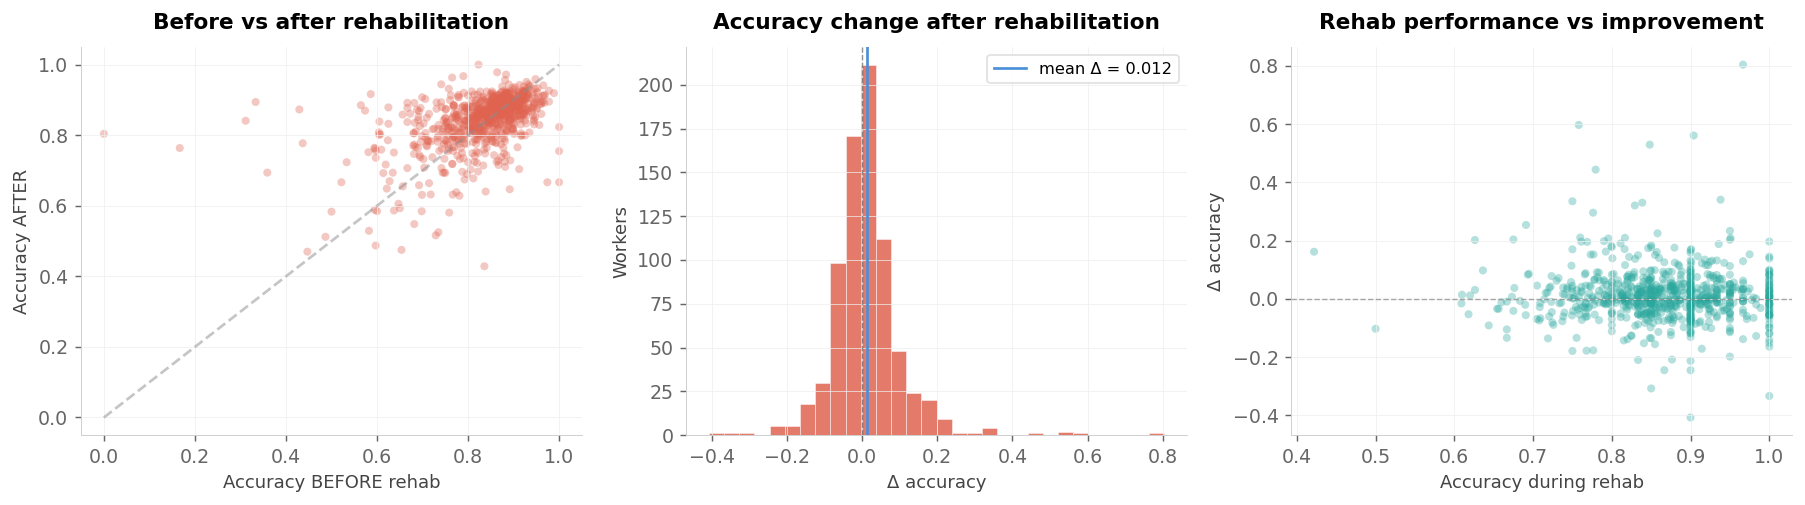

Workers with sufficient before/after data: 765
Accuracy before: 0.8269
Accuracy after:  0.8393
Mean Δ:          +0.0124
Improved:  413 (54%)
Worsened:  352 (46%)

Wilcoxon signed-rank test: W = 127716, p = 0.0021


In [57]:
rehab_ids = df[df["pool_type"]==1]["ozon_id"].unique()

results = []
for wid in rehab_ids:
    ws = df[df["ozon_id"]==wid].sort_values("created_at")
    t0 = ws[ws["pool_type"]==1]["created_at"].min()
    
    before = ws[(ws["pool_type"]==0) & (ws["created_at"] < t0) & ws["correct"].notna()]
    after  = ws[(ws["pool_type"]==0) & (ws["created_at"] > t0) & ws["correct"].notna()]
    rehab  = ws[(ws["pool_type"]==1) & ws["correct"].notna()]
    
    if len(before) >= 5 and len(after) >= 5:
        results.append({
            "acc_before": before["correct"].mean(),
            "acc_after":  after["correct"].mean(),
            "acc_rehab":  rehab["correct"].mean() if len(rehab) else np.nan,
            "n_before": len(before), "n_after": len(after),
            "delta": after["correct"].mean() - before["correct"].mean(),
        })
rdf = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# a) before vs after
axes[0].scatter(rdf["acc_before"], rdf["acc_after"], alpha=0.35, s=20,
                color=C["coral"], edgecolors="none")
axes[0].plot([0,1],[0,1], "--", color=C["gray"], alpha=0.5)
axes[0].set_xlabel("Accuracy BEFORE rehab"); axes[0].set_ylabel("Accuracy AFTER")
axes[0].set_title("Before vs after rehabilitation"); despine(axes[0])

# b) delta histogram
axes[1].hist(rdf["delta"], bins=30, color=C["coral"], alpha=0.85,
             edgecolor="white", lw=0.3)
axes[1].axvline(0, color="#333", ls="--", lw=0.8, alpha=0.5)
axes[1].axvline(rdf["delta"].mean(), color=C["blue"], lw=1.5,
                label=f"mean Δ = {rdf['delta'].mean():.3f}")
axes[1].set_title("Accuracy change after rehabilitation")
axes[1].set_xlabel("Δ accuracy"); axes[1].set_ylabel("Workers")
axes[1].legend(); despine(axes[1])

# c) rehab performance vs improvement
axes[2].scatter(rdf["acc_rehab"], rdf["delta"], alpha=0.35, s=20,
                color=C["teal"], edgecolors="none")
axes[2].axhline(0, color="#333", ls="--", lw=0.8, alpha=0.4)
axes[2].set_xlabel("Accuracy during rehab"); axes[2].set_ylabel("Δ accuracy")
axes[2].set_title("Rehab performance vs improvement"); despine(axes[2])

plt.tight_layout(); plt.show()

print(f"Workers with sufficient before/after data: {len(rdf)}")
print(f"Accuracy before: {rdf['acc_before'].mean():.4f}")
print(f"Accuracy after:  {rdf['acc_after'].mean():.4f}")
print(f"Mean Δ:          {rdf['delta'].mean():+.4f}")
print(f"Improved:  {(rdf['delta']>0).sum()} ({(rdf['delta']>0).mean()*100:.0f}%)")
print(f"Worsened:  {(rdf['delta']<0).sum()} ({(rdf['delta']<0).mean()*100:.0f}%)")

stat, pval = stats.wilcoxon(rdf["acc_before"], rdf["acc_after"])
print(f"\nWilcoxon signed-rank test: W = {stat:.0f}, p = {pval:.4f}")

**Rehabilitation shows a small but statistically significant positive effect.** Among 765 workers with sufficient before/after data:

- Accuracy **before** rehab: 82.7 %
- Accuracy **after** rehab: 83.9 %
- Mean delta = **+1.24 pp** (Wilcoxon p = 0.002)
- 54 % improved, 46 % worsened.

The effect is real but modest. Possible confounds:
1. **Regression to the mean** — workers enter rehab after a bad streak and would partially recover anyway.
2. **Survivorship bias** — workers who quit after rehab are excluded; those who stay may be more engaged.
3. **The 100 K sample showed the opposite** (delta ~ -0.01) — a reminder that sample-based conclusions can be misleading.

### 17.1 · Before/after accuracy distribution

In [ ]:
# ── Cleaner replacement for per-worker timeline chart ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# a) paired histogram: before vs after
bins = np.linspace(0.4, 1.0, 25)
axes[0].hist(rdf["acc_before"], bins=bins, alpha=0.55, color=C["coral"],
             edgecolor="white", lw=0.3, label="Before rehab")
axes[0].hist(rdf["acc_after"], bins=bins, alpha=0.55, color=C["teal"],
             edgecolor="white", lw=0.3, label="After rehab")
axes[0].axvline(rdf["acc_before"].mean(), color=C["coral"], ls="--", lw=1.2)
axes[0].axvline(rdf["acc_after"].mean(),  color=C["teal"],  ls="--", lw=1.2)
axes[0].set_xlabel("Accuracy"); axes[0].set_ylabel("Workers")
axes[0].set_title("Accuracy distribution: before vs after rehab")
axes[0].legend(); despine(axes[0])

# b) mean improvement by initial-accuracy bucket
rdf["before_bin"] = pd.cut(
    rdf["acc_before"],
    bins=[0, 0.6, 0.7, 0.8, 0.9, 1.01],
    labels=["<60%", "60-70%", "70-80%", "80-90%", "90-100%"])
bucket = rdf.groupby("before_bin", observed=True)["delta"].agg(["mean", "count"])

bars = axes[1].bar(
    bucket.index.astype(str), bucket["mean"],
    color=[C["coral"] if v < 0 else C["teal"] for v in bucket["mean"]],
    alpha=0.85, width=0.6)
for b, (_, r) in zip(bars, bucket.iterrows()):
    y = b.get_height()
    axes[1].text(b.get_x() + b.get_width() / 2,
                 y + (0.004 if y >= 0 else -0.009),
                 f"n={r['count']:.0f}", ha="center", fontsize=8)
axes[1].axhline(0, color="#333", ls="-", lw=0.5, alpha=0.3)
axes[1].set_xlabel("Accuracy before rehab")
axes[1].set_ylabel("Mean delta accuracy")
axes[1].set_title("Who benefits from rehabilitation?")
despine(axes[1])

plt.tight_layout(); plt.show()

**Who benefits?** The paired histogram shows the "after" distribution shifted slightly right relative to "before". The bucket chart reveals that **the weakest workers benefit most**: those below 60 % gain the largest improvement, while workers above 90 % tend to regress slightly. This is consistent with a combination of genuine rehabilitation effect *and* regression to the mean — the two are difficult to disentangle without a randomised control group.

## 18 · Summary and next steps

### Key findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **4.12 M answers, 14 452 workers, 5 projects** over one month | Substantial statistical power for modelling |
| 2 | **Long-tail activity**: 11 % one-shot, 7.5 % power workers produce most volume | Worker quality must be estimated with models, not raw counts |
| 3 | **Binary task structure**: 96–98 % of errors are 1-vs-2 swaps | Simplifies aggregation to binary classification |
| 4 | **Class imbalance**: 58–73 % label 1 across projects | Baseline "always 1" = 58–73 %; must account for it |
| 5 | **Rehabilitation helps slightly**: +1.2 pp, p = 0.002, 54 % improve | Real but modest; strongest for weakest workers; regression-to-mean confound |
| 6 | **Faster = more accurate**: 91 % at 5 s vs 88 % at 79 s | Confounded by task difficulty, not a speed-quality trade-off |
| 7 | **Overlap = 5 targets hard tasks** | Selection bias — not a failure of redundancy |
| 8 | **71 % of tasks are unanimous** | Aggregation challenge lies in the 29 % borderline cases |
| 9 | **Skippers are less accurate** (minus 3.5 pp) | Skipping signals disengagement, not conscientiousness |
| 10 | **Gold accuracy is a reliable quality proxy** (corr with agreement rate) | Validates gold tasks as ground truth for model evaluation |

### Next steps

1. **Aggregation**: Dawid-Skene, GLAD, MACE — infer true labels and latent worker reliability; benchmark against gold accuracy.
2. **Segmentation**: Cluster workers using the 21-feature table from section 15; interpret segments and link to platform actions.
3. **Cost-quality trade-off**: Simulate adaptive overlap — fewer workers for easy tasks, more for hard ones.
4. **Rehabilitation ROI**: Test whether targeted rehab (difficulty-graded tasks, personalised feedback) outperforms the current flat approach.